## 🚨 Anomaly Detection (Fraud Detection)

### 🧠 Objective:

Detect fraudulent transactions from a highly imbalanced dataset using Isolation Forest.

---

### ⚙️ Approach:

* Scaled all features using StandardScaler
* Applied Isolation Forest for anomaly detection
* Set contamination based on expected fraud ratio

---

### 📊 Key Results:

* Model detected anomalies close to actual fraud count
* However, many fraud cases were missed initially (low recall)

---

### ⚖️ Precision vs Recall Trade-off:

* Increasing contamination improved **recall** (more fraud detected)
* But reduced **precision** (more false alarms)

---

### 💡 Insight:

In fraud detection, **recall is more important than precision**, as missing a fraudulent transaction is more critical than raising a false alert.

---

### ✅ Conclusion:

Isolation Forest is effective for detecting anomalies in imbalanced data, but careful tuning of contamination is required to balance precision and recall.

---


In [108]:
import pandas as pd

df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [110]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.274539e-12,-9.512736e-13,-4.398678e-13,-1.029671e-13,-3.838944e-13,7.529013e-13,-3.405412e-14,-1.660106e-13,1.027627e-13,...,-4.078958e-13,-9.849381e-13,-1.763859e-13,4.203004e-13,1.603967e-13,2.986665e-13,2.308042e-12,-2.239082e-12,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [111]:
df.groupby("Class")["Class"].count()

Class
0    284315
1       492
Name: Class, dtype: int64

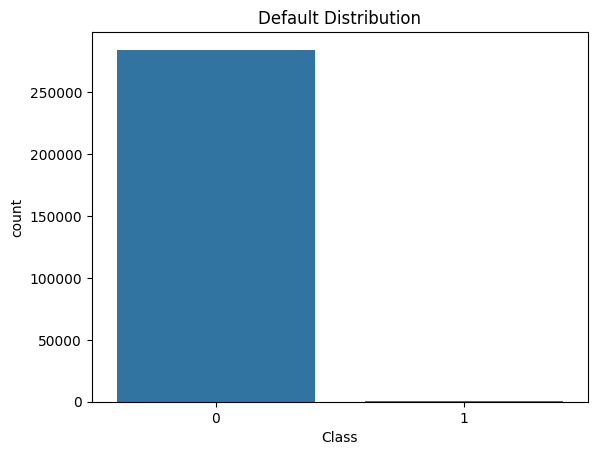

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Class",data=df)
plt.title("Default Distribution")
plt.show()

In [113]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [114]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [115]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.003, random_state=42)
df["anomaly"] = model.fit_predict(X_scaled)

In [116]:
df["anomaly"] = df["anomaly"].map({1: 0, -1: 1})
print(df["anomaly"].value_counts())

anomaly
0    283952
1       855
Name: count, dtype: int64


In [117]:
df[df["anomaly"] == 1].head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,anomaly
164,103.0,-6.093248,-12.114213,-5.694973,3.294389,-1.413792,4.776000,4.808426,-0.228197,-0.525896,...,-2.264037,-3.553381,1.215279,-0.406073,-0.653384,-0.711222,0.672900,3828.04,0,1
1388,1077.0,-3.936794,-3.670519,-1.453820,2.299750,-9.749440,6.456410,10.784088,-2.160016,-0.238116,...,0.957186,2.441960,0.250607,0.300908,1.157867,1.624284,-1.638647,2452.03,0,1
1632,1264.0,-11.140706,-9.612726,-12.389545,6.013346,-32.092129,21.393069,34.303177,-7.520784,-1.925732,...,1.366110,-2.925888,0.843551,0.746267,0.801387,3.852046,4.157934,7712.43,0,1
2178,1698.0,-5.849226,-11.754975,-3.333303,3.673246,-4.459583,0.659098,4.527224,-0.985512,0.237794,...,-1.992179,-3.240351,0.609619,-0.985548,0.089693,-0.713355,0.653060,3669.00,0,1
2622,2151.0,-2.574940,-2.669331,-3.080133,2.043551,-11.416881,7.885721,12.219249,-1.828209,-1.475925,...,0.264090,2.219739,-0.771131,0.145438,-0.240517,1.180441,-0.623651,2909.97,0,1


In [118]:
from sklearn.metrics import classification_report

print(classification_report(df["Class"], df["anomaly"]))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.21      0.36      0.26       492

    accuracy                           1.00    284807
   macro avg       0.60      0.68      0.63    284807
weighted avg       1.00      1.00      1.00    284807



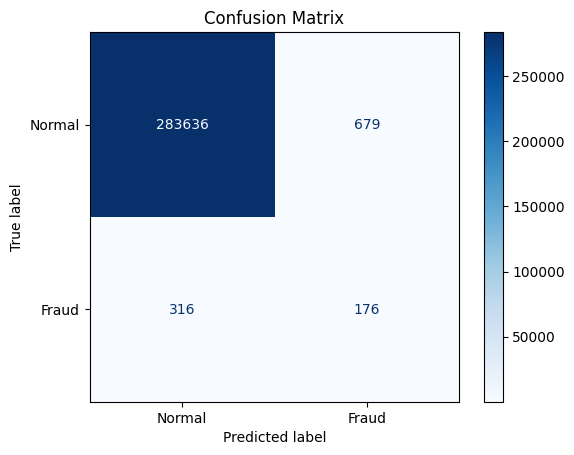

In [119]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(df["Class"],df["anomaly"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Normal", "Fraud"])

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()